# Generalized Propensity Score — Education & Earnings

Estimates the causal dose-response relationship between years of education
and 1978 earnings using the Generalized Propensity Score (Hirano & Imbens, 2004).

| | |
|---|---|
| **Treatment** | `educ` — years of education (continuous) |
| **Outcome** | `re78` — real earnings in 1978 (USD) |
| **Dataset** | LaLonde (1986) NSW data via Dehejia & Wahba (1999) |

**Key difference from binary PSM:** instead of a single ATT number, GPS produces
a **dose-response curve** — earnings as a function of years of schooling.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [8]:
DATA_DIR = Path("../data/raw")

COLUMNS = ["treat", "age", "educ", "black", "hisp", "married", "nodegree", "re74", "re75", "re78"]

treated = pd.read_csv(DATA_DIR / "nswre74_treated.txt", sep=r"\s+", header=None, names=COLUMNS)
control = pd.read_csv(DATA_DIR / "nswre74_control.txt", sep=r"\s+", header=None, names=COLUMNS)

df = pd.concat([treated, control], ignore_index=True)

TREATMENT = "educ"
OUTCOME   = "re78"

print(f"Shape       : {df.shape}")
print(f"\nEducation (treatment):")
print(df[TREATMENT].describe())
print(f"\nEarnings 1978 (outcome):")
print(df[OUTCOME].describe())

Shape       : (445, 10)

Education (treatment):
count    445.000000
mean      10.195506
std        1.792119
min        3.000000
25%        9.000000
50%       10.000000
75%       11.000000
max       16.000000
Name: educ, dtype: float64

Earnings 1978 (outcome):
count      445.000000
mean      5300.763699
std       6631.491695
min          0.000000
25%          0.000000
50%       3701.812000
75%       8124.715000
max      60307.930000
Name: re78, dtype: float64


## EDA: Education distribution and unadjusted earnings

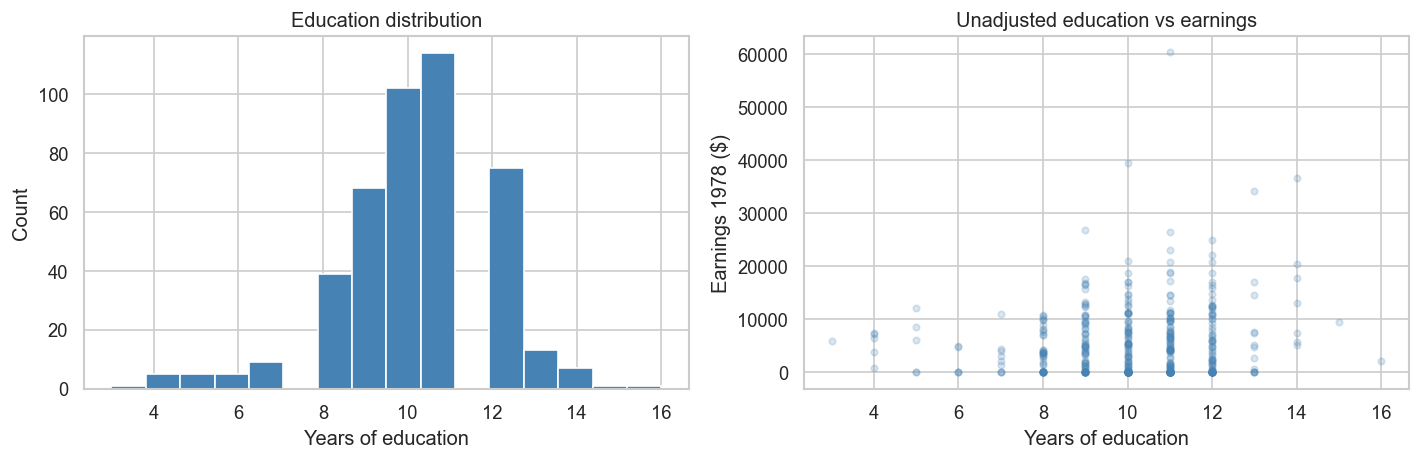

Education range : 3 – 16 years
Unique values   : [np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0)]


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[TREATMENT].hist(ax=axes[0], bins=16, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Years of education")
axes[0].set_ylabel("Count")
axes[0].set_title("Education distribution")

axes[1].scatter(df[TREATMENT], df[OUTCOME], alpha=0.2, s=15, color="steelblue")
axes[1].set_xlabel("Years of education")
axes[1].set_ylabel("Earnings 1978 ($)")
axes[1].set_title("Unadjusted education vs earnings")

plt.tight_layout()
plt.show()

print(f"Education range : {df[TREATMENT].min():.0f} – {df[TREATMENT].max():.0f} years")
print(f"Unique values   : {sorted(df[TREATMENT].unique())}")

## Step 1 — GPS estimation

Model education as a function of covariates using OLS. The GPS for each
observation is the height of the fitted normal density at their actual education value:

```
GPS_i = f(T_i | X_i) = Normal(T_i; μ_i, σ²)
```

A high GPS means "this person's education level was not surprising given their background."
A low GPS means their education was unusual for someone with their observed characteristics.

In [ ]:
from scipy.stats import norm

COVARIATES = ["age", "black", "hisp", "married", "nodegree", "re74", "re75"]

treatment_model = smf.ols(
    f"{TREATMENT} ~ {' + '.join(COVARIATES)}",
    data=df
).fit()

print(treatment_model.summary().tables[1])
print(f"\nR²  : {treatment_model.rsquared:.3f}")
print(f"σ̂   : {np.sqrt(treatment_model.mse_resid):.3f}")

In [ ]:
sigma = np.sqrt(treatment_model.mse_resid)
mu    = treatment_model.fittedvalues

# GPS = height of normal density at each person's actual education value
df['gps'] = norm.pdf(df[TREATMENT], loc=mu, scale=sigma)

print(df['gps'].describe().round(4))

plt.figure(figsize=(6, 4))
df['gps'].hist(bins=40, color="steelblue", edgecolor="white")
plt.xlabel("GPS value")
plt.title("Distribution of GPS scores")
plt.show()

## Step 2 — Covariate balance check

In binary PSM we check balance at one threshold (treated vs control).
With GPS we check balance across education strata — divide education into
low / medium / high bins and verify that covariates are similar within each bin
after adjusting for the GPS.

In [ ]:
df['educ_bin'] = pd.cut(
    df[TREATMENT],
    bins=[0, 10, 12, 20],
    labels=["Low (≤10)", "Medium (11–12)", "High (≥13)"]
)

balance = df.groupby('educ_bin', observed=True)[COVARIATES].mean().T
print("Unadjusted covariate means by education stratum:")
print(balance.round(2))

## Step 3 — Dose-response function estimation

Hirano & Imbens (2004) estimate the dose-response function in two steps:

1. **Outcome model**: regress Y on T and GPS (and T², GPS², T×GPS for flexibility)
2. **Integration**: for each treatment level t, predict the outcome averaging the GPS across all observations evaluated at t

This averages out the confounding — holding GPS constant removes the selection bias.

In [ ]:
df['educ_sq'] = df[TREATMENT] ** 2
df['gps_sq']  = df['gps'] ** 2
df['educ_gps'] = df[TREATMENT] * df['gps']

outcome_model = smf.ols(
    f"{OUTCOME} ~ {TREATMENT} + educ_sq + gps + gps_sq + educ_gps",
    data=df
).fit()

print(outcome_model.summary().tables[1])

In [ ]:
# For each education level t, compute the GPS each person would have at t,
# then average predicted earnings across all n observations.
# This marginalises out the GPS, giving E[Y(t)] — the dose-response curve.

t_grid = np.arange(df[TREATMENT].min(), df[TREATMENT].max() + 1)
dose_response = []

for t in t_grid:
    gps_at_t   = norm.pdf(t, loc=mu, scale=sigma)
    pred_frame = pd.DataFrame({
        TREATMENT:  t,
        'educ_sq':  t ** 2,
        'gps':      gps_at_t,
        'gps_sq':   gps_at_t ** 2,
        'educ_gps': t * gps_at_t,
    })
    preds = outcome_model.predict(pred_frame)
    dose_response.append(preds.mean())

drf = pd.DataFrame({"educ": t_grid, "earnings_adj": dose_response})
print(drf)

## Step 4 — Dose-response curve

Plot the GPS-adjusted dose-response curve alongside the unadjusted raw means.
The gap between them shows how much confounding was present.

In [ ]:
raw_means = df.groupby(TREATMENT)[OUTCOME].mean().reset_index()
raw_means.columns = ["educ", "earnings_raw"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(raw_means["educ"], raw_means["earnings_raw"],
        "o--", color="grey", alpha=0.7, label="Unadjusted raw means")
ax.plot(drf["educ"], drf["earnings_adj"],
        "o-", color="steelblue", linewidth=2, label="GPS-adjusted dose-response")

ax.set_xlabel("Years of education")
ax.set_ylabel("Earnings 1978 ($)")
ax.set_title("Dose-response curve: education → earnings (GPS-adjusted)")
ax.legend()
plt.tight_layout()
plt.show()